# Housing Data from an API and a Relational Database

This notebook completes our two assigned data-source sections without changing the existing regression notebook:

1. Retrieve Ontario housing-supply data from an official CKAN web API.
2. Save the API response as JSON and convert the records to a pandas DataFrame.
3. Store the data in a portable SQLite relational database using SQLAlchemy.
4. Run SQL selection and filtering queries.
5. Perform basic exploratory analysis with summary statistics and plots.

## 1. Import the required packages

- `requests` communicates with the API.
- `pandas` organizes the returned records into a table.
- `SQLAlchemy` connects Python to SQLite and runs SQL.
- `matplotlib` creates the EDA plots.

In [3]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import requests
from IPython.display import display
from sqlalchemy import create_engine, inspect, text

## 2. Locate the project folders

The code works when the notebook is opened from either the project root or its `notebooks` folder.

In [4]:
PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

RAW_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
RAW_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Raw data folder:", RAW_DIR)
print("Processed data folder:", PROCESSED_DIR)

Project root: C:\Users\Lenovo\Documents\linear_regression_project
Raw data folder: C:\Users\Lenovo\Documents\linear_regression_project\data\raw
Processed data folder: C:\Users\Lenovo\Documents\linear_regression_project\data\processed


# Part A — Web API

Ontario's CKAN Data API returns structured JSON. The `resource_id` identifies the official January–December 2024 Ontario housing-supply resource. No API key is required.

In [5]:
API_URL = "https://data.ontario.ca/api/3/action/datastore_search"
RESOURCE_ID = "3bb04ba5-2445-44e0-9d2c-8a25dd1b18e6"

response = requests.get(
    API_URL,
    params={"resource_id": RESOURCE_ID, "limit": 1000},
    timeout=60,
)
response.raise_for_status()
api_payload = response.json()

if not api_payload.get("success"):
    raise RuntimeError("The Ontario API reported an unsuccessful request.")

records = api_payload["result"]["records"]
print(f"Records returned by API: {len(records)}")

Records returned by API: 51


## 3. Save the raw API response

Saving the original JSON preserves exactly what the API returned. This supports reproducibility because the raw response remains separate from later cleaning.

In [6]:
json_path = RAW_DIR / "ontario_housing_api_2024.json"
with json_path.open("w", encoding="utf-8") as file:
    json.dump(api_payload, file, indent=2, ensure_ascii=False)

print("Raw API response saved to:", json_path)

Raw API response saved to: C:\Users\Lenovo\Documents\linear_regression_project\data\raw\ontario_housing_api_2024.json


## 4. Convert the API records to a DataFrame

The API returns a list of records. `pd.DataFrame(records)` turns that list into rows and columns.

In [7]:
api_df = pd.DataFrame(records)

print("API DataFrame shape:", api_df.shape)
print("API columns:", api_df.columns.tolist())
display(api_df.head())

API DataFrame shape: (51, 8)
API columns: ['_id', 'Municipality', 'Ten-year housing target', 'Total housing progress since 2022', 'Target for 2024', 'Total 2024 housing progress', 'Progress % for 2024', 'Housing target status']


,_id,Municipality,Ten-year housing target,Total housing progress since 2022,Target for 2024,Total 2024 housing progress,Progress % for 2024,Housing target status
0,1,Ajax,17000,1908,1417,270,19.05%,Not met
1,2,Aurora,8000,663,667,189,28.34%,Not met
2,3,Barrie,23000,5450,1917,1459,76.11%,Not met
3,4,Belleville,3100,1177,258,250,96.90%,On track
4,5,Bradford West Gwillimbury,6500,1015,542,263,48.52%,Not met


## 5. Clean numeric fields

CKAN may return numeric-looking values as text. We convert the count columns to numbers and remove the `%` sign from the progress column.

In [8]:
ontario_api_df = api_df.copy()

numeric_columns = [
    "Ten-year housing target",
    "Total housing progress since 2022",
    "Target for 2024",
    "Total 2024 housing progress",
]

for column in numeric_columns:
    ontario_api_df[column] = pd.to_numeric(ontario_api_df[column], errors="coerce")

ontario_api_df["Progress percentage 2024"] = pd.to_numeric(
    ontario_api_df["Progress % for 2024"]
    .astype(str)
    .str.replace("%", "", regex=False),
    errors="coerce",
)

processed_csv = PROCESSED_DIR / "ontario_housing_api_2024_clean.csv"
ontario_api_df.to_csv(processed_csv, index=False)

print("Cleaned data saved to:", processed_csv)
display(ontario_api_df.head())

Cleaned data saved to: C:\Users\Lenovo\Documents\linear_regression_project\data\processed\ontario_housing_api_2024_clean.csv


,_id,Municipality,Ten-year housing target,Total housing progress since 2022,Target for 2024,Total 2024 housing progress,Progress % for 2024,Housing target status,Progress percentage 2024
0,1,Ajax,17000,1908,1417,270,19.05%,Not met,19.05
1,2,Aurora,8000,663,667,189,28.34%,Not met,28.34
2,3,Barrie,23000,5450,1917,1459,76.11%,Not met,76.11
3,4,Belleville,3100,1177,258,250,96.90%,On track,96.90
4,5,Bradford West Gwillimbury,6500,1015,542,263,48.52%,Not met,48.52


## 6. Basic EDA for the API data

We inspect summary statistics and compare annual targets with actual 2024 progress.

,count,mean,std,min,25%,50%,75%,max
Ten-year housing target,51.0,29411.764706,51710.836957,1000.00,5950.000,12000.00,25000.000,285000.00
Total housing progress since 2022,51.0,6126.490196,12528.015162,558.00,1054.500,1955.00,5191.000,74339.00
Target for 2024,51.0,2450.980392,4309.148568,83.00,496.000,1000.00,2083.500,23750.00
Total 2024 housing progress,51.0,1860.941176,3519.548962,60.00,293.500,741.00,1957.000,20999.00
Progress percentage 2024,51.0,97.560392,82.975032,11.07,47.805,80.66,115.005,479.52


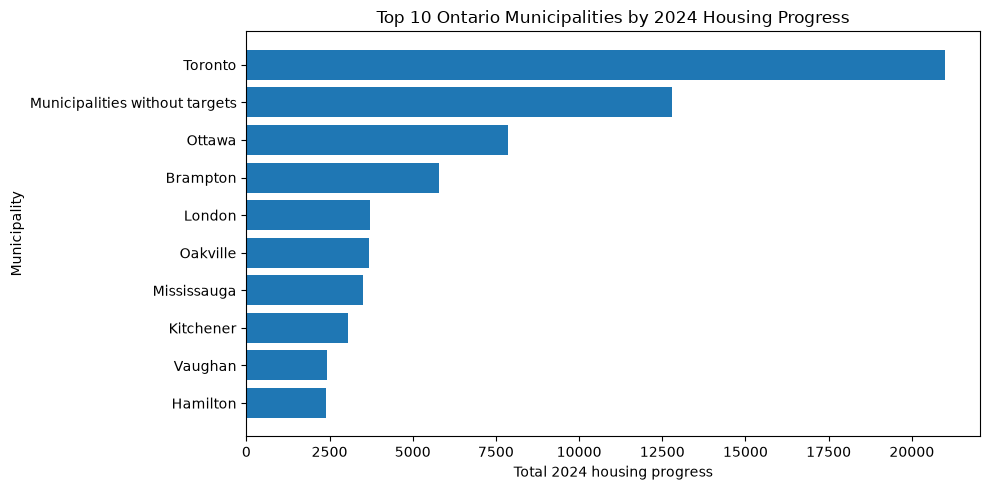

In [9]:
display(ontario_api_df[numeric_columns + ["Progress percentage 2024"]].describe().T)

top_progress = ontario_api_df.nlargest(10, "Total 2024 housing progress")

plt.figure(figsize=(10, 5))
plt.barh(top_progress["Municipality"], top_progress["Total 2024 housing progress"])
plt.xlabel("Total 2024 housing progress")
plt.ylabel("Municipality")
plt.title("Top 10 Ontario Municipalities by 2024 Housing Progress")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Part B — Relational Database

SQLite is permitted by the assignment and is portable because the complete database is stored in one local file. SQLAlchemy provides the connection between pandas, Python, and SQLite.

In [10]:
database_path = RAW_DIR / "housing_data.sqlite"
engine = create_engine(f"sqlite:///{database_path}")

ontario_api_df.to_sql(
    name="ontario_housing_progress",
    con=engine,
    if_exists="replace",
    index=False,
)

print("SQLite database created at:", database_path)
print("Tables:", inspect(engine).get_table_names())

SQLite database created at: C:\Users\Lenovo\Documents\linear_regression_project\data\raw\housing_data.sqlite
Tables: ['ontario_housing_progress']


## 7. SQL selection query

This query selects specific columns instead of loading the entire table. It sorts municipalities by their 2024 housing progress.

In [11]:
selection_query = text(
    '''
    SELECT
        "Municipality",
        "Target for 2024",
        "Total 2024 housing progress",
        "Progress percentage 2024",
        "Housing target status"
    FROM ontario_housing_progress
    ORDER BY "Total 2024 housing progress" DESC
    LIMIT 10
    '''
)

with engine.connect() as connection:
    selected_df = pd.read_sql_query(selection_query, connection)

display(selected_df)

,Municipality,Target for 2024,Total 2024 housing progress,Progress percentage 2024,Housing target status
0,Toronto,23750,20999,88.42,On track
1,Municipalities without targets,14390,12802,88.96,Not applicable
2,Ottawa,12583,7871,62.55,Not met
3,Brampton,9417,5791,61.50,Not met
4,London,3917,3723,95.05,On track
5,Oakville,2750,3679,133.78,Exceeded
6,Mississauga,10000,3496,34.96,Not met
7,Kitchener,2917,3067,105.14,Exceeded
8,Vaughan,3500,2431,69.46,Not met
9,Hamilton,3917,2384,60.86,Not met


## 8. SQL filtering query

This query uses a `WHERE` condition to return municipalities that reached at least 80% of their 2024 target. The threshold is passed as a parameter rather than inserted directly into the SQL string.

In [12]:
minimum_progress = 80

filter_query = text(
    '''
    SELECT
        "Municipality",
        "Progress percentage 2024",
        "Housing target status"
    FROM ontario_housing_progress
    WHERE "Progress percentage 2024" >= :minimum_progress
    ORDER BY "Progress percentage 2024" DESC
    '''
)

with engine.connect() as connection:
    filtered_df = pd.read_sql_query(
        filter_query,
        connection,
        params={"minimum_progress": minimum_progress},
    )

print(f"Municipalities at or above {minimum_progress}%: {len(filtered_df)}")
display(filtered_df)

Municipalities at or above 80%: 26


,Municipality,Progress percentage 2024,Housing target status
0,North Bay,479.52,Exceeded
1,Chatham-Kent,338.04,Exceeded
2,Greater Sudbury,264.98,Exceeded
3,Windsor,212.93,Exceeded
4,Sarnia,197.59,Exceeded
5,Pickering,173.59,Exceeded
6,Sault Ste. Marie,151.20,Exceeded
7,Kingston,144.83,Exceeded
8,Thunder Bay,143.17,Exceeded
9,Oakville,133.78,Exceeded


## 9. Verify database loading with a plot

The following plot uses `filtered_df`, which came from the SQL query rather than directly from the API DataFrame. This confirms that the database data can be used for analysis.

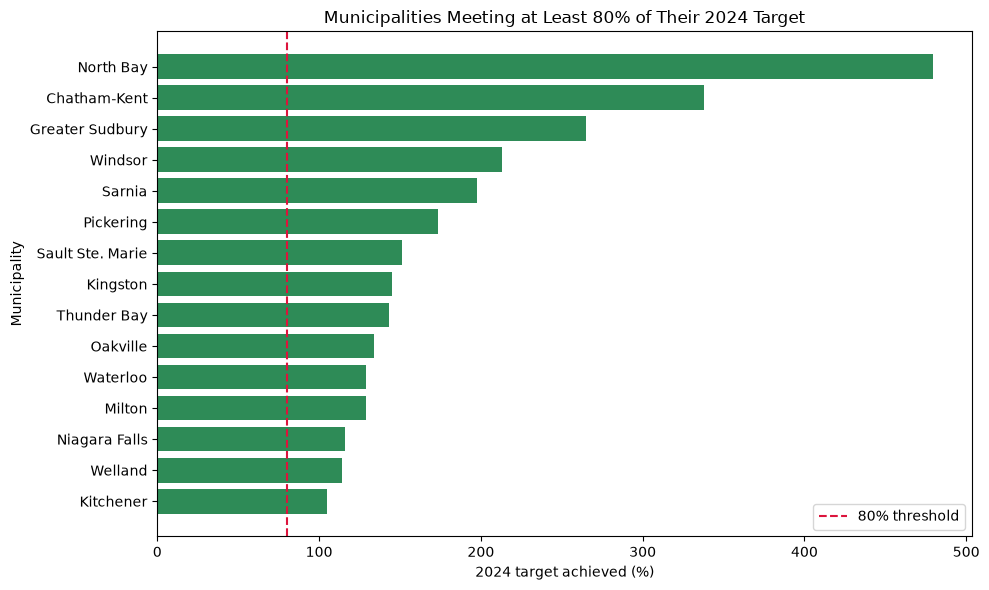

In [13]:
plot_df = filtered_df.head(15).sort_values("Progress percentage 2024")

plt.figure(figsize=(10, 6))
plt.barh(plot_df["Municipality"], plot_df["Progress percentage 2024"], color="seagreen")
plt.axvline(minimum_progress, color="crimson", linestyle="--", label="80% threshold")
plt.xlabel("2024 target achieved (%)")
plt.ylabel("Municipality")
plt.title("Municipalities Meeting at Least 80% of Their 2024 Target")
plt.legend()
plt.tight_layout()
plt.show()

## What our part completes

- Used `requests` to retrieve JSON from an official public web API.
- Saved the unmodified API response in `data/raw/`.
- Converted API records into a pandas DataFrame.
- Cleaned numeric fields and saved processed data.
- Created a portable SQLite relational database.
- Used SQLAlchemy to connect to the database.
- Ran SQL `SELECT`, `WHERE`, `ORDER BY`, and `LIMIT` operations.
- Produced summary statistics and plots from API and database data.

This notebook covers the API and relational-database parts of the data-sourcing deliverable. It does not replace the separate regression notebook.